## Problem Statement
* Understanding Aadhaar Activity and Identifying Unusual Service Demand Across Districts

* Aadhaar-related services involve more than just new enrolments. People also update their demographic and biometric information, and the amount of this activity can vary across different districts, age groups, and time periods.

* When we only look at the total number of enrolments or updates, it becomes difficult to understand what is actually happening in each district. A district may have high activity because of consistently high demand, while another district may suddenly experience an unusual increase in updates or enrolments. These patterns can easily be missed when we focus only on overall numbers.

* The main aim of this project is to explore Aadhaar enrolment and update data using Exploratory Data Analysis (EDA) and identify meaningful patterns in service activity across districts.

* The analysis focuses on three main areas:

  * 1.Enrolment Patterns: Understanding where Aadhaar enrolment is higher and how it changes across districts, age groups, and time.
  * 2.Update Activity: Identifying districts where demographic and biometric updates are relatively high compared to enrolments.
  * 3.Unusual Patterns: Finding districts or time periods where Aadhaar activity is significantly different from the usual pattern.

* By analyzing trends over time, demographic distribution, enrolment and update ratios, and district-level activity, this project aims to go beyond simple rankings and better understand how Aadhaar service demand differs across locations.

* Question

- Which districts show unusual Aadhaar activity patterns, and what can these patterns tell us about possible differences in service demand?

- The goal is not to make assumptions about why these patterns occur, but to use the available data to highlight interesting trends and areas that may need further attention.

### Import Libraries

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


### STEP 1: DATA UNDERSTANDING & CLEANING

In [96]:
df = pd.read_csv(r"C:\Users\Shrapti\Downloads\UIDAI.csv",parse_dates=["date"])

# observation: parase_date = this automatically converts the date column into datetime format while loading the data.

In [97]:
df.head()

,Unnamed: 0,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
0,0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271
1,1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327
2,2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753
3,3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583
4,4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426


In [98]:
df=df.drop(columns=["Unnamed: 0"])
df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271
1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327
2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753
3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583
4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94955 entries, 0 to 94954
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            94955 non-null  datetime64[us]
 1   state           94955 non-null  str           
 2   district        94955 non-null  str           
 3   pincode         94955 non-null  int64         
 4   age_0_5         94955 non-null  int64         
 5   age_5_17        94955 non-null  int64         
 6   age_18_greater  94955 non-null  int64         
 7   demo_age_5_17   94955 non-null  int64         
 8   demo_age_17_    94955 non-null  int64         
 9   bio_age_5_17    94955 non-null  int64         
 10  bio_age_17_     94955 non-null  int64         
dtypes: datetime64[us](1), int64(8), str(2)
memory usage: 9.6 MB


In [100]:

print("STEP 1: DATA UNDERSTANDING & CLEANING")

print("Shape:\n", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nDate Range:", df["date"].min(), "to", df["date"].max())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nUnique States:", df["state"].nunique())
print("Unique Districts:", df["district"].nunique())
print("Unique Pincodes:", df["pincode"].nunique())



STEP 1: DATA UNDERSTANDING & CLEANING
Shape:
 (94955, 11)

Data Types:
 date              datetime64[us]
state                        str
district                     str
pincode                    int64
age_0_5                    int64
age_5_17                   int64
age_18_greater             int64
demo_age_5_17              int64
demo_age_17_               int64
bio_age_5_17               int64
bio_age_17_                int64
dtype: object

Date Range: 2025-04-01 00:00:00 to 2025-09-19 00:00:00

Missing Values:
 date              0
state             0
district          0
pincode           0
age_0_5           0
age_5_17          0
age_18_greater    0
demo_age_5_17     0
demo_age_17_      0
bio_age_5_17      0
bio_age_17_       0
dtype: int64

Duplicate Rows: 2927

Unique States: 46
Unique Districts: 880
Unique Pincodes: 17560


In [101]:
# Remove duplicates if present
df = df.drop_duplicates()


In [102]:
df.duplicated().sum()


np.int64(0)

In [103]:
df['state'].unique()

<ArrowStringArray>
[                              'Tamil Nadu',
                                'Rajasthan',
                           'Madhya Pradesh',
                               'Chandigarh',
                                'Karnataka',
                                    'Delhi',
                                  'Gujarat',
                                   'Punjab',
                                    'Assam',
                            'Uttar Pradesh',
                              'Maharashtra',
                              'West Bengal',
                             'Chhattisgarh',
                                  'Haryana',
                              'Uttarakhand',
                                    'Bihar',
                        'Jammu and Kashmir',
                                  'Mizoram',
                                'Telangana',
                           'Andhra Pradesh',
                        'Arunachal Pradesh',
                   'Dadra and Nagar 

In [104]:
# Clean inconsistent state names
state_fix = {
    "Orissa": "Odisha",
    "Pondicherry": "Puducherry",
    "andhra pradesh": "Andhra Pradesh",
    "Westbengal": "West Bengal",
    "Jammu & Kashmir": "Jammu and Kashmir",
    "Andaman & Nicobar Islands": "Andaman and Nicobar Islands",
    "Dadra & Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",
    "Dadra and Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",
    "Daman & Diu": "Dadra and Nagar Haveli and Daman and Diu",
    "Daman and Diu": "Dadra and Nagar Haveli and Daman and Diu",
}
df["state_clean"] = df["state"].replace(state_fix)



In [105]:
df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,state_clean
0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,Tamil Nadu
1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,Rajasthan
2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,Madhya Pradesh
3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,Madhya Pradesh
4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,Chandigarh


In [106]:
df['state_clean'].unique()

<ArrowStringArray>
[                              'Tamil Nadu',
                                'Rajasthan',
                           'Madhya Pradesh',
                               'Chandigarh',
                                'Karnataka',
                                    'Delhi',
                                  'Gujarat',
                                   'Punjab',
                                    'Assam',
                            'Uttar Pradesh',
                              'Maharashtra',
                              'West Bengal',
                             'Chhattisgarh',
                                  'Haryana',
                              'Uttarakhand',
                                    'Bihar',
                        'Jammu and Kashmir',
                                  'Mizoram',
                                'Telangana',
                           'Andhra Pradesh',
                        'Arunachal Pradesh',
 'Dadra and Nagar Haveli and Daman a

In [107]:
# Clean state names
df["state_clean"] = df["state"].astype(str).str.strip().str.title()

# Clean district names
df["district_clean"] = df["district"].astype(str).str.strip().str.title()

In [108]:
# Pincode validation
df["pincode_clean"] = df["pincode"].astype(str).str.replace(".0", "", regex=False)
df["valid_pincode"] = df["pincode_clean"].str.match(r"^\d{6}$")
print("\nInvalid Pincodes:", (~df["valid_pincode"]).sum())
print(df.head())



Invalid Pincodes: 0
        date           state      district  pincode  age_0_5  age_5_17  \
0 2025-04-01      Tamil Nadu  Kancheepuram   600045       81        19   
1 2025-04-01       Rajasthan      Jhalawar   326038      112        49   
2 2025-04-01  Madhya Pradesh        Raisen   464551      291        39   
3 2025-04-01  Madhya Pradesh          Dhar   454001      253        74   
4 2025-04-01      Chandigarh    Chandigarh   160036       86        21   

   age_18_greater  demo_age_5_17  demo_age_17_  bio_age_5_17  bio_age_17_  \
0              14             53           502           193          271   
1              12             76           588           152          327   
2              12            213          1030          1989          753   
3              75            372          1804          1775         1583   
4              10            400          1441           542          426   

      state_clean district_clean pincode_clean  valid_pincode  
0      

In [109]:
# Check data coverage
print("\nRows per Month:")
print(df["date"].dt.to_period("M").value_counts().sort_index())




Rows per Month:
date
2025-04       72
2025-05       55
2025-06       31
2025-07       72
2025-09    91798
Freq: M, Name: count, dtype: int64


In [110]:
# Dense period used for detailed daily analysis
daily_data = df[df["date"] >= "2025-09-01"].copy()


### STEP 2: FEATURE ENGINEERING

In [111]:
daily_data["total_enrolment"] = (
    daily_data["age_0_5"]
    + daily_data["age_5_17"]
    + daily_data["age_18_greater"]
)

daily_data["total_demo_updates"] = (
    daily_data["demo_age_5_17"]
    + daily_data["demo_age_17_"]
)

daily_data["total_bio_updates"] = (
    daily_data["bio_age_5_17"]
    + daily_data["bio_age_17_"]
)

daily_data["total_updates"] = (
    daily_data["total_demo_updates"]
    + daily_data["total_bio_updates"]
)

daily_data["year"] = daily_data["date"].dt.year
daily_data["month"] = daily_data["date"].dt.month
daily_data["weekday"] = daily_data["date"].dt.day_name()

daily_data["is_weekend"] = daily_data["weekday"].isin(
    ["Saturday", "Sunday"]
)

In [112]:
print(daily_data.columns.tolist())

['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17', 'age_18_greater', 'demo_age_5_17', 'demo_age_17_', 'bio_age_5_17', 'bio_age_17_', 'state_clean', 'district_clean', 'pincode_clean', 'valid_pincode', 'total_enrolment', 'total_demo_updates', 'total_bio_updates', 'total_updates', 'year', 'month', 'weekday', 'is_weekend']


### STEP 3: UNIVARIATE ANALYSIS


STEP 3: UNIVARIATE ANALYSIS


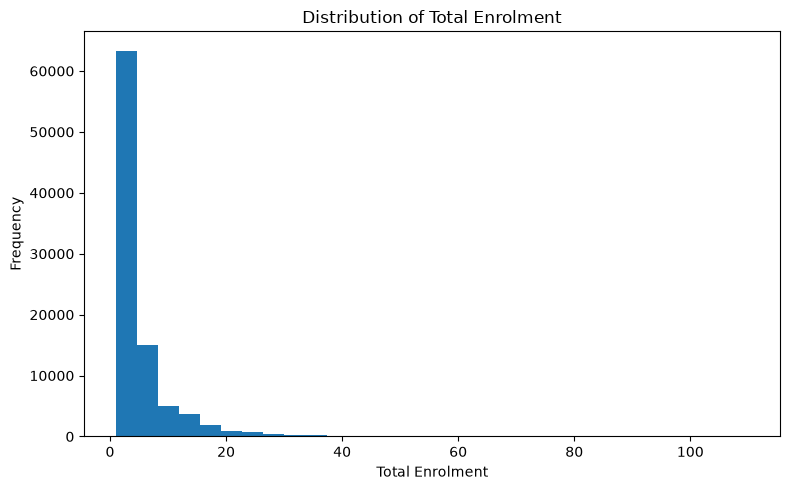

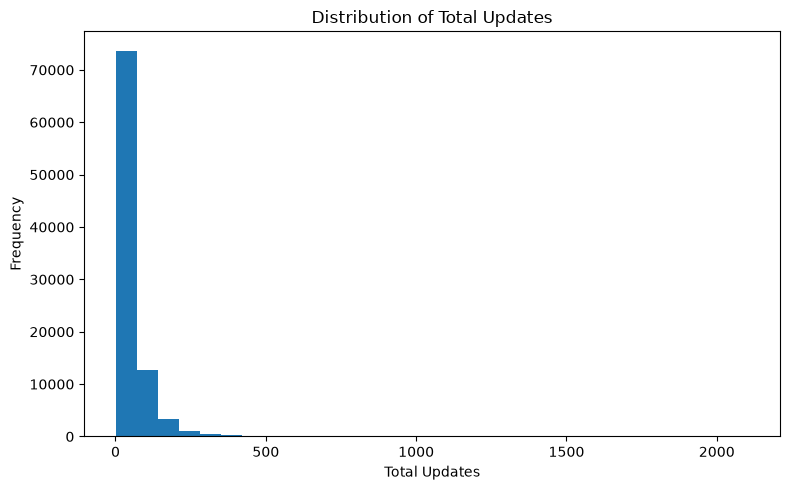

Districts contributing ~80% activity: 339


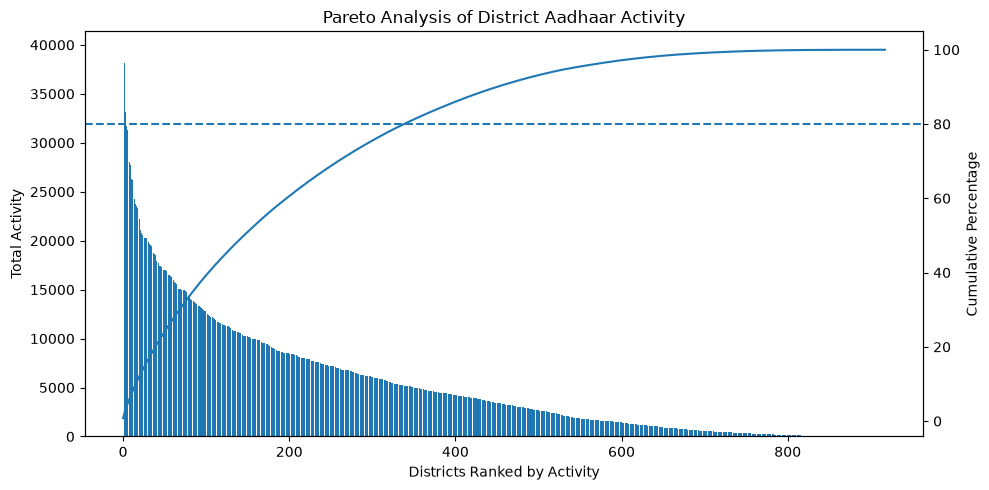

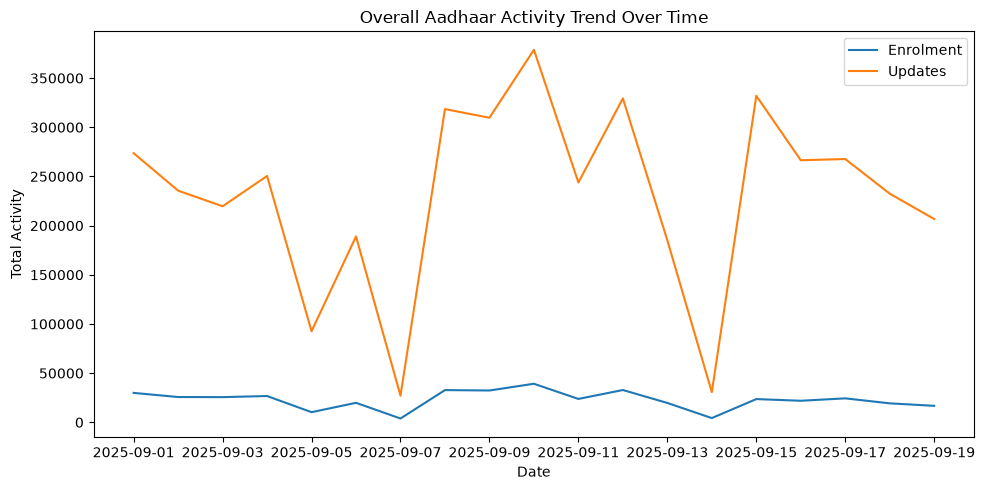

In [113]:
print("\n" + "=" * 60)
print("STEP 3: UNIVARIATE ANALYSIS")
print("=" * 60)

# Distribution: Enrolment
plt.figure(figsize=(8, 5))
plt.hist(daily_data["total_enrolment"], bins=30)
plt.title("Distribution of Total Enrolment")
plt.xlabel("Total Enrolment")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("chart_1_enrolment_distribution.png")
plt.show()

# Distribution: Updates
plt.figure(figsize=(8, 5))
plt.hist(daily_data["total_updates"], bins=30)
plt.title("Distribution of Total Updates")
plt.xlabel("Total Updates")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("chart_2_updates_distribution.png")
plt.show()

# District-level aggregation
district_tbl = (
    daily_data.groupby(["state_clean", "district_clean"])
    .agg(
        total_enrolment=("total_enrolment", "sum"),
        total_updates=("total_updates", "sum"),
        child_enrolment=("age_0_5", "sum"),
        days_active=("date", "nunique")
    )
    .reset_index()
)

district_tbl["update_to_enrolment_ratio"] = (
    district_tbl["total_updates"]
    / district_tbl["total_enrolment"].replace(0, np.nan)
)

district_tbl["child_share"] = (
    district_tbl["child_enrolment"]
    / district_tbl["total_enrolment"].replace(0, np.nan)
)

district_tbl["total_volume"] = (
    district_tbl["total_enrolment"] + district_tbl["total_updates"]
)

district_tbl = district_tbl.fillna(0)

# Pareto Analysis
ranked = district_tbl.sort_values("total_volume", ascending=False).reset_index(drop=True)
ranked["cumulative_percentage"] = (
    ranked["total_volume"].cumsum() / ranked["total_volume"].sum() * 100
)

districts_for_80 = (ranked["cumulative_percentage"] <= 80).sum()
print("Districts contributing ~80% activity:", districts_for_80)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(len(ranked)), ranked["total_volume"])
ax1.set_xlabel("Districts Ranked by Activity")
ax1.set_ylabel("Total Activity")

ax2 = ax1.twinx()
ax2.plot(range(len(ranked)), ranked["cumulative_percentage"])
ax2.set_ylabel("Cumulative Percentage")
ax2.axhline(80, linestyle="--")

plt.title("Pareto Analysis of District Aadhaar Activity")
plt.tight_layout()
plt.savefig("chart_3_pareto.png")
plt.show()

# Overall Trend
daily_trend = daily_data.groupby("date")[["total_enrolment", "total_updates"]].sum()

plt.figure(figsize=(10, 5))
plt.plot(daily_trend.index, daily_trend["total_enrolment"], label="Enrolment")
plt.plot(daily_trend.index, daily_trend["total_updates"], label="Updates")
plt.title("Overall Aadhaar Activity Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Activity")
plt.legend()
plt.tight_layout()
plt.savefig("chart_4_activity_trend.png")
plt.show()


### STEP 4: BIVARIATE ANALYSIS

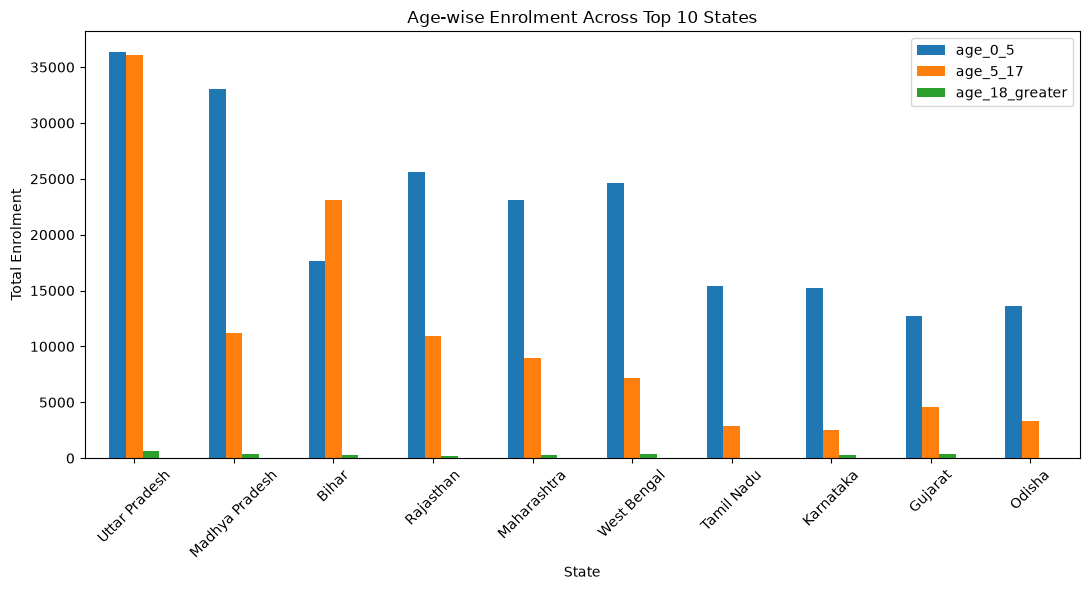


Average Activity by Weekday:
            total_enrolment  total_updates
weekday                                  
Monday            4.689147      50.221564
Tuesday           5.014988      50.899849
Wednesday         4.914953      47.738522
Thursday          4.694020      48.884577
Friday            4.392098      46.084885
Saturday          4.550472      43.098064
Sunday            3.855728      27.226780


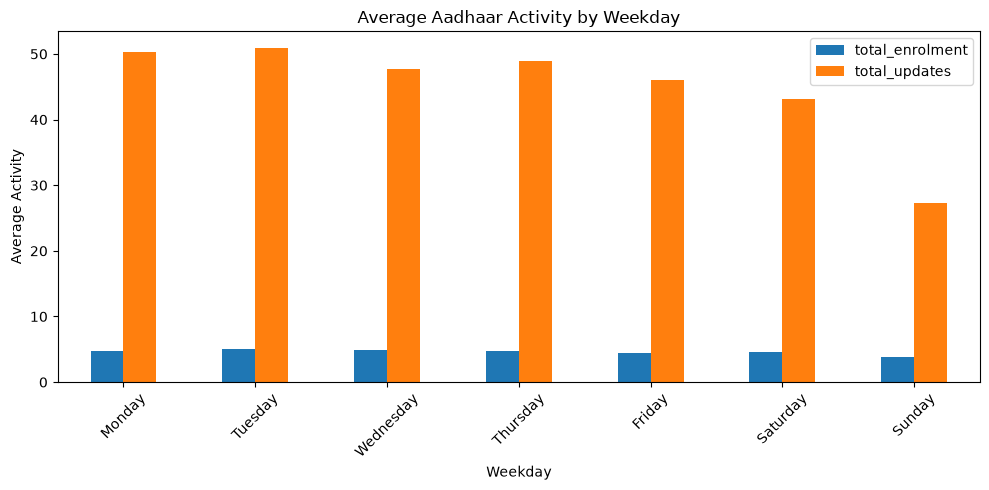

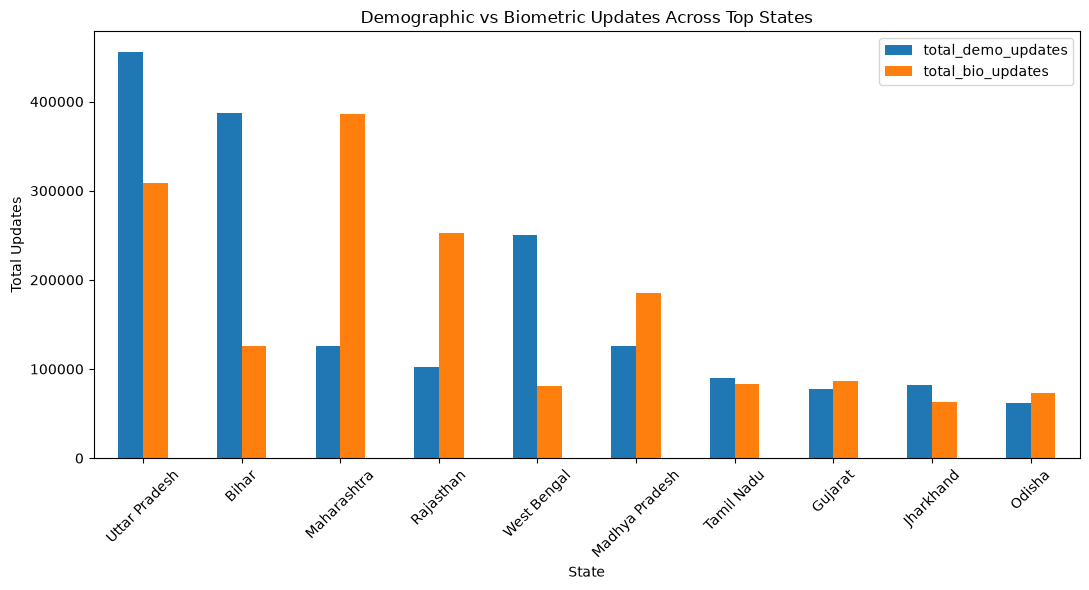

In [114]:
# Age Group vs State
state_age = daily_data.groupby("state_clean")[
    ["age_0_5", "age_5_17", "age_18_greater"]
].sum()

state_age["total"] = state_age.sum(axis=1)
top_states = state_age.sort_values("total", ascending=False).head(10).drop(columns="total")

top_states.plot(kind="bar", figsize=(11, 6))
plt.title("Age-wise Enrolment Across Top 10 States")
plt.xlabel("State")
plt.ylabel("Total Enrolment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart_5_age_vs_state.png")
plt.show()

# Weekday vs Activity
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_activity = (
    daily_data.groupby("weekday")[["total_enrolment", "total_updates"]]
    .mean()
    .reindex(weekday_order)
)

print("\nAverage Activity by Weekday:\n", weekday_activity)

weekday_activity.plot(kind="bar", figsize=(10, 5))
plt.title("Average Aadhaar Activity by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Activity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart_6_weekday.png")
plt.show()

# Update Type vs Geography
state_updates = daily_data.groupby("state_clean")[
    ["total_demo_updates", "total_bio_updates"]
].sum()

state_updates["total"] = state_updates.sum(axis=1)
top_update_states = (
    state_updates.sort_values("total", ascending=False)
    .head(10)
    .drop(columns="total")
)

top_update_states.plot(kind="bar", figsize=(11, 6))
plt.title("Demographic vs Biometric Updates Across Top States")
plt.xlabel("State")
plt.ylabel("Total Updates")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart_7_update_type_geography.png")
plt.show()


### STEP 5: MULTIVARIATE ANALYSIS

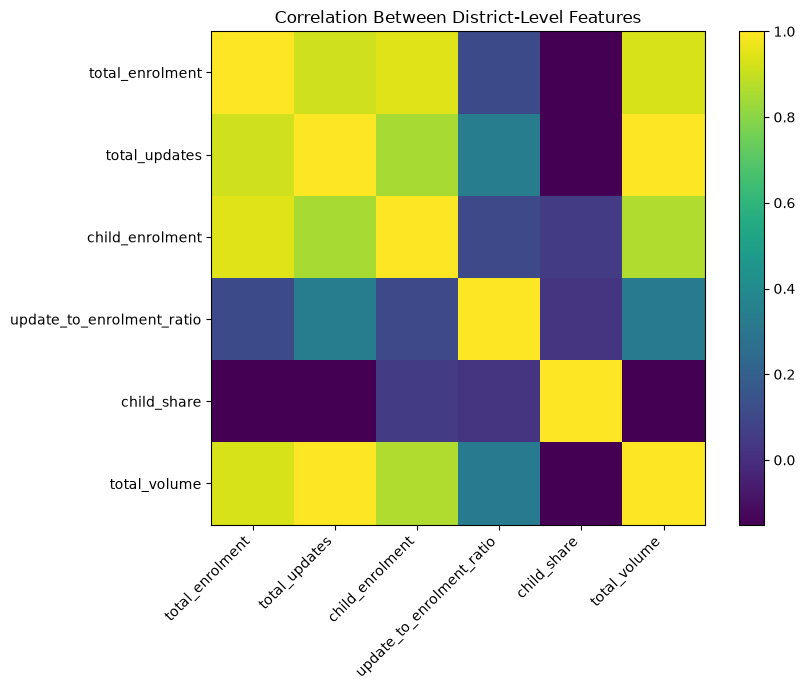


Correlation Matrix:
                            total_enrolment  total_updates  child_enrolment  \
total_enrolment                       1.00           0.92             0.94   
total_updates                         0.92           1.00             0.85   
child_enrolment                       0.94           0.85             1.00   
update_to_enrolment_ratio             0.11           0.34             0.10   
child_share                          -0.15          -0.15             0.05   
total_volume                          0.93           1.00             0.86   

                           update_to_enrolment_ratio  child_share  \
total_enrolment                                 0.11        -0.15   
total_updates                                   0.34        -0.15   
child_enrolment                                 0.10         0.05   
update_to_enrolment_ratio                       1.00         0.02   
child_share                                     0.02         1.00   
total_volume     

C:\Users\Shrapti\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


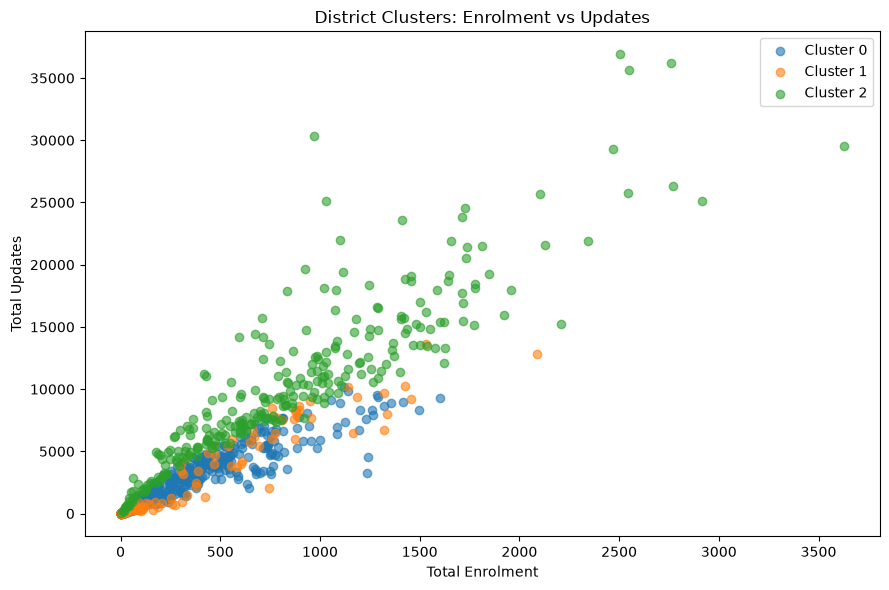

In [115]:
# Correlation Analysis
correlation_columns = [
    "total_enrolment",
    "total_updates",
    "child_enrolment",
    "update_to_enrolment_ratio",
    "child_share",
    "total_volume"
]

corr = district_tbl[correlation_columns].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Between District-Level Features")
plt.tight_layout()
plt.savefig("chart_8_correlation.png")
plt.show()

print("\nCorrelation Matrix:\n", corr.round(2))
# KMeans Clustering
features = ["total_volume", "update_to_enrolment_ratio", "child_share"]

X = district_tbl[features].copy()

# Limit extreme values
X["update_to_enrolment_ratio"] = X["update_to_enrolment_ratio"].clip(
    upper=X["update_to_enrolment_ratio"].quantile(0.95)
)

X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
district_tbl["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = (
    district_tbl.groupby("cluster")
    .agg(
        avg_volume=("total_volume", "mean"),
        avg_enrolment=("total_enrolment", "mean"),
        avg_updates=("total_updates", "mean"),
        avg_update_ratio=("update_to_enrolment_ratio", "mean"),
        avg_child_share=("child_share", "mean")
    )
)

print("\nCluster Summary:\n", cluster_summary.round(2))

# Cluster Chart
plt.figure(figsize=(9, 6))

for cluster in sorted(district_tbl["cluster"].unique()):
    cluster_data = district_tbl[district_tbl["cluster"] == cluster]
    plt.scatter(
        cluster_data["total_enrolment"],
        cluster_data["total_updates"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Total Enrolment")
plt.ylabel("Total Updates")
plt.title("District Clusters: Enrolment vs Updates")
plt.legend()
plt.tight_layout()
plt.savefig("chart_9_clusters.png")
plt.show()


### STEP 6: ANOMALY DETECTION

In [116]:
daily_district = (
    daily_data.groupby(["state_clean", "district_clean", "date"])["total_enrolment"]
    .sum()
    .reset_index()
)

daily_district["z_score"] = (
    daily_district.groupby(["state_clean", "district_clean"])["total_enrolment"]
    .transform(
        lambda x: (x - x.mean()) / x.std(ddof=0)
        if x.std(ddof=0) > 0 else 0
    )
)

top_anomalies = daily_district.loc[
    daily_district["z_score"].abs().sort_values(ascending=False).index
].head(10)

print("\nTop 10 Anomalies:")
print(
    top_anomalies[
        ["state_clean", "district_clean", "date", "total_enrolment", "z_score"]
    ]
)


Top 10 Anomalies:
          state_clean district_clean       date  total_enrolment   z_score
5326        Karnataka         Mysuru 2025-09-01               75  3.833648
13189     West Bengal     Koch Bihar 2025-09-02               60  3.731558
11364   Uttar Pradesh        Ayodhya 2025-09-04               27  3.639555
2457     Chhattisgarh        Raigarh 2025-09-08               90  3.587717
12477   Uttar Pradesh        Sambhal 2025-09-10              165  3.543169
1133            Assam      Kokrajhar 2025-09-01               60  3.512603
9590        Rajasthan       Jhalawar 2025-09-12              215  3.493512
993             Assam       Golaghat 2025-09-05               96  3.489469
9513        Rajasthan    Hanumangarh 2025-09-08               88  3.271543
6056   Madhya Pradesh        Dindori 2025-09-08               62  3.258689


### STEP 7: PRESCRIPTIVE LAYER

In [117]:
# Rule-based recommendation using district behaviour
def recommend_action(row):
    if row["total_volume"] == 0:
        return "Review data availability"
    elif row["update_to_enrolment_ratio"] > 2:
        return "Prioritize update services"
    elif row["child_share"] > 0.30:
        return "Prioritize child enrolment services"
    else:
        return "Maintain balanced services"

district_tbl["recommendation"] = district_tbl.apply(recommend_action, axis=1)

print("\nRecommendation Distribution:")
print(district_tbl["recommendation"].value_counts())




Recommendation Distribution:
recommendation
Prioritize update services             905
Maintain balanced services               7
Prioritize child enrolment services      6
Name: count, dtype: int64


### STEP 8: SAVE RESULTS

In [119]:

district_tbl.sort_values("total_volume", ascending=False).to_csv(
    "district_summary.csv", index=False
)

top_anomalies.to_csv("top_anomalies.csv", index=False)

district_tbl[
    [
        "state_clean",
        "district_clean",
        "total_volume",
        "update_to_enrolment_ratio",
        "child_share",
        "recommendation"
    ]
].to_csv("district_recommendations.csv", index=False)


print("PROJECT COMPLETED SUCCESSFULLY!")

print("""
Main Analysis:
1. Data Understanding & Cleaning
2. Feature Engineering
3. Univariate Analysis
4. Bivariate Analysis
5. Multivariate Analysis
6. Anomaly Detection
7. Prescriptive Analysis
8. Insights and Recommendations
""")


PROJECT COMPLETED SUCCESSFULLY!

Main Analysis:
1. Data Understanding & Cleaning
2. Feature Engineering
3. Univariate Analysis
4. Bivariate Analysis
5. Multivariate Analysis
6. Anomaly Detection
7. Prescriptive Analysis
8. Insights and Recommendations



#### Based on the exploratory data analysis, the following key patterns were observed:

1. **Enrolment Patterns**
   - Identify the districts/states with the highest Aadhaar enrolment activity.
   - Observe how enrolment differs across age groups.

2. **Update Activity**
   - Compare demographic and biometric updates with total enrolment.
   - Identify districts with high update intensity.

3. **Temporal Trends**
   - Analyze how Aadhaar activity changes over time.
   - Identify periods with unusually high or low activity.

4. **District-Level Behaviour**
   - Compare districts based on total volume and update-to-enrolment ratios.
   - Highlight districts showing different activity patterns.

5. **Anomalies**
   - Identify districts or time periods where activity significantly deviates from the general pattern.

### Final Conclusion

The analysis shows that Aadhaar activity cannot be understood by looking only at total enrolment numbers. Different districts demonstrate different patterns of enrolment and update activity. By combining demographic analysis, temporal trends, ratios, and anomaly detection, the project helps identify districts with unusual activity patterns that may require further investigation.